# Application of WAVEGUISE to a 25-day pressure time series from the Strateole-2 campaign
During the Strateole-2 campaign long-duration superpressure balloons equipped with a number of sensors was floating at equatorial latitudes. At an altitude of approximately 50hPa the balloon was sampling temperature, pressure, wind, humidity, etc. I'm investigating the pressure data and aim to separate periodic structures from gravity waves, tides, and planetary waves. Simultaneously, the spectral properties of the identified wave packets are extracted.

This script serves to generate Figure 1 from Reichert et al. (in prep.) hopefully soon submitted to AMT.

In [1]:
import sys
sys.path.append('/home/r/Robert.Reichert/juwavelet')
import juwavelet.transform as transform
from juwavelet import utils
sys.path.append('../scripts')
import utils_1d as one

import copy
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats, ndimage
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.signal import find_peaks
import matplotlib.colors as mcolors

plt.style.use("../latex_default_AMT.mplstyle")

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
ST2_path = '../data/ST2_C0_01_STR1_TSEN_v03b.nc'
ds = xr.open_dataset(ST2_path)
ds = ds.isel(time=slice(0,600*60*2))

In [3]:
# Prepare the data for wavelet transform
dt = 30/3_600
nt = len(ds['time'])
time = np.linspace(dt,nt*dt,nt)
orig = ds['pressure'].values
p_high, p_low = one.BG_removal(orig,max_order=1)

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(p_high, ntap, window='tukey')

# Compute the wavelet transform
s0 = 20*dt
dj = 1/8
js = int(1/dj*np.log2(nt*dt/s0))
cwt_result = transform.decompose1d(signal, dt, s0, dj, js, opts={'param': 2*np.pi}, mode="scaled", dtype=np.complex128)

# Denoising
noise_floor = 0.1 #units of hPa
wavy_stuff, denoised_cwt = one.denoise_1d(cwt_result,white_noise_level=noise_floor)

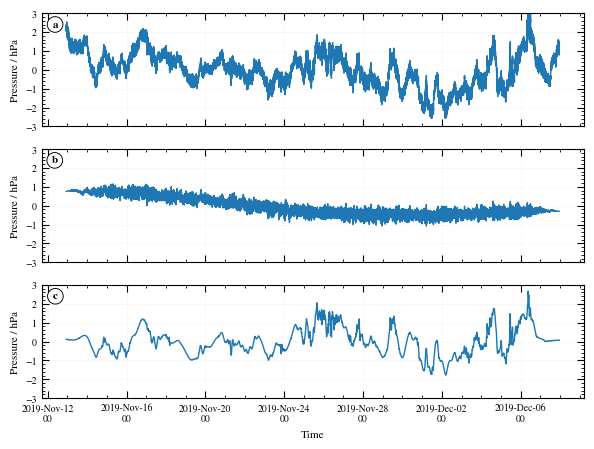

In [16]:
import sys
sys.path.append('/home/r/Robert.Reichert/sexy-wave')
import plotting_cosmetics as pc
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.dates as mdates

fig=plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(311)
ax1.plot(ds['time'],ds['pressure'].values)
ax2 = fig.add_subplot(312)
ax2.plot(ds['time'],p_low+signal-wavy_stuff)
ax3 = fig.add_subplot(313)
ax3.plot(ds['time'],wavy_stuff)
ax1.set_ylim([-3,3])
ax2.set_ylim([-3,3])
ax3.set_ylim([-3,3])

ax1.set_ylabel('Pressure / hPa')
ax2.set_ylabel('Pressure / hPa')
ax3.set_ylabel('Pressure / hPa')

hlocator = mdates.DayLocator(interval=4)
ax1.xaxis.set_major_formatter(pc.timelab_format_func)
ax2.xaxis.set_major_formatter(pc.timelab_format_func)
ax3.xaxis.set_major_formatter(pc.timelab_format_func)
ax1.xaxis.set_major_locator(hlocator)
ax2.xaxis.set_major_locator(hlocator)
ax3.xaxis.set_major_locator(hlocator)
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax2.xaxis.set_minor_locator(AutoMinorLocator())
ax3.xaxis.set_minor_locator(AutoMinorLocator())

ax1.yaxis.set_major_locator(MultipleLocator(1))
ax2.yaxis.set_major_locator(MultipleLocator(1))
ax3.yaxis.set_major_locator(MultipleLocator(1))
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax2.yaxis.set_minor_locator(AutoMinorLocator())
ax3.yaxis.set_minor_locator(AutoMinorLocator())

ax1.tick_params(which="both", labelbottom=False, labeltop=False)
ax2.tick_params(which="both", labelbottom=False, labeltop=False)
ax3.tick_params(which="both", labelbottom=True, labeltop=False)
ax3.set_xlabel('Time')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

plt.savefig('./figures/1D_example_Strateole-2_BG_removal.png',dpi=300,bbox_inches="tight",pad_inches=0.02)

## Segmentation

In [7]:
WPS    = np.abs(denoised_cwt['decomposition'])**2
seg_v1 = one.wavefield_segmentation_1d(WPS,noise_floor**2,connectivity_order=2)
print('Identified', np.max(seg_v1), 'initial wave packets!')
WP_labels      = np.arange(1,np.max(seg_v1)+1)
cluster_labels = one.find_clusters_in_freq(denoised_cwt, seg_v1)
cluster_map    = one.build_cluster_map_with_noise(WP_labels,cluster_labels)
seg_v2         = one.relabel_by_x_overlap(seg_v1, cluster_map)
print('Reduced the number of wave packets to', np.max(seg_v2))
seg_v3         = one.variance_filter(denoised_cwt, seg_v2, var_threshold=0.99)
print('Final number of wave packets:', np.max(seg_v3))

Identified 91 initial wave packets!
Reduced the number of wave packets to 49
Final number of wave packets: 14


In [8]:
recon_seg, amp_seg, freq_seg = one.recon_WP_and_properties_1d(denoised_cwt,seg_v3)

/scratch-local/slurm-job-tmp-13601325/ipykernel_4198/3006087232.py:1: RuntimeWarning: divide by zero encountered in divide
  per_seg = 2*np.pi/freq_seg


Text(0.03, 0.9, 'b')

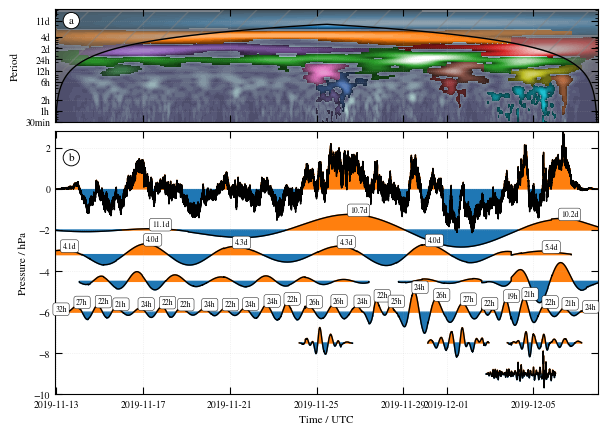

In [9]:
per_seg = 2*np.pi/freq_seg
TIME, PERIOD = np.meshgrid(ds['time'], cwt_result["period"])
WPS = np.abs(cwt_result['decomposition'])

font_size='x-small'
letter = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple',
    'tab:brown','tab:pink','tab:olive','tab:cyan',
    '#4C72B0',  # gedämpftes Blau (ähnlich tab:blue, aber unterscheidbar)
    '#DD8452',  # warmes Orange
    '#55A868',  # weiches Grün
    '#C44E52',  # dunkleres Rot
    '#8172B3',  # entsättigtes Violett
    '#937860'   # graubraunes Neutral
]
titlebox = {"boxstyle": "round", "lw": 0.33, "facecolor": "white", "edgecolor": "black"}
letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": [1], "height_ratios": [3,7]}

fig, ax=plt.subplots(2, 1, figsize=(7,5), gridspec_kw=gskw, sharex=True)

ax[0].contourf(TIME, PERIOD, WPS, levels=np.linspace(-0.2,0.4,31), extend='max', cmap='bone')
#plt.colorbar(location="right", orientation="vertical", label="Wave amplitude / hPa",ticks=[0,0.1,0.2,0.3,0.4,0.5])
ax[0].set_yscale("log")
ax[0].set_ylabel("Period")
ax[0].set_yticks([0.5,1,2,6,12,24,48,4*24,11*24],['30min','1h','2h','6h','12h','24h','2d','4d','11d'])
ax[0].set_ylim([0.5,np.max(cwt_result['period'])])

for lab in np.unique(seg_v3):
    if lab == 0:
        continue
    mask     = (seg_v3 == lab)
    if not np.any(mask):
        continue
    #flat_idx = np.argmax(np.where(mask, WPS, -np.inf))
    #iy, ix   = np.unravel_index(flat_idx, WPS.shape)
    #center_x = TIME[iy, ix]
    #center_y = PERIOD[iy, ix]
    #ax[0].text(center_x,center_y,str(lab),color="k",fontsize=8,ha="center",va="center",bbox=dict(facecolor="white", alpha=0.8))

    mask = (seg_v3 == lab) & (WPS > noise_floor)
    masked_WPS = np.ma.masked_where(~mask, WPS)
    # Base color
    base = mcolors.to_rgb(colors[lab-1])
    
    # Create custom colormap: white -> orange -> black
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "white_orange_black",
        [
            (0.0, (1, 1, 1)),   # white
            (0.5, base),        # tab:orange
            (1.0, (0, 0, 0))    # black
        ]
    )
    ax[0].contourf(TIME, PERIOD, masked_WPS, levels=np.linspace(0,0.6,31), cmap=cmap.reversed(), extend='both')

x2 = time
order=2*np.pi
coi_x = np.minimum(x2,x2[-1]-x2)
coi_boundary_scale = coi_x / np.sqrt(2)
coi_boundary_wavelength = 4*np.pi*coi_boundary_scale/(order+np.sqrt(2+order**2))
ax[0].plot(ds['time'], coi_boundary_wavelength, c='k')
ax[0].fill_between(ds['time'], coi_boundary_wavelength, y2=np.max(cwt_result['period']), hatch='/', color='grey', alpha=0.5)

# ORIGINAL
ax[1].fill_between(ds['time'],signal,where=signal<0)
ax[1].fill_between(ds['time'],signal,where=signal>0,color='tab:orange')
ax[1].plot(ds['time'], signal, c='k')
ax[1].set_ylabel('Pressure / hPa')
ax[1].set_ylim([-10,2.8])

# 11-DAY WAVE
offset=-2.0
peaks, _ = find_peaks(recon_seg[0],distance=np.median(per_seg[0])*60)
ax[1].fill_between(ds['time'],recon_seg[0]+offset,y2=offset,where=recon_seg[0]<0,color='tab:blue')
ax[1].fill_between(ds['time'],recon_seg[0]+offset,y2=offset,where=recon_seg[0]>0,color='tab:orange')
ax[1].plot(ds['time'],recon_seg[0]+offset,c='k')
for label in peaks:
    ax[1].text(ds['time'][label],recon_seg[0][label]+offset,f"{per_seg[0][label]/24:.1f}d", va='bottom', ha='left', bbox=titlebox, size=font_size)

# 4-DAY WAVE
offset=-3.2
peaks, _ = find_peaks(recon_seg[1],distance=np.median(per_seg[1])*60)
ax[1].fill_between(ds['time'],recon_seg[1]+offset,y2=offset,where=recon_seg[1]<0,color='tab:blue')
ax[1].fill_between(ds['time'],recon_seg[1]+offset,y2=offset,where=recon_seg[1]>0,color='tab:orange')
ax[1].plot(ds['time'],np.where(amp_seg[1]==0,np.nan,recon_seg[1]+offset),c='k')
for label in peaks:
    if np.isfinite(per_seg[1][label]):
        ax[1].text(ds['time'][label],recon_seg[1][label]+offset,f"{per_seg[1][label]/24:.1f}d", va='bottom', ha='left', bbox=titlebox, size=font_size)

# 2-DAY WAVE
offset=-4.5
#peaks, _ = find_peaks(recon_seg[3],distance=np.median(per_seg[3])*60)
ax[1].fill_between(ds['time'],recon_seg[3]+recon_seg[4]+offset,y2=offset,where=recon_seg[3]+recon_seg[4]<0,color='tab:blue')
ax[1].fill_between(ds['time'],recon_seg[3]+recon_seg[4]+offset,y2=offset,where=recon_seg[3]+recon_seg[4]>0,color='tab:orange')
ax[1].plot(ds['time'],np.where(amp_seg[3]+amp_seg[4]==0,np.nan,recon_seg[3]+recon_seg[4]+offset),c='k')
#for label in peaks:
#    ax[1].text(ds['time'][label],recon_seg[3][label]+offset,f"{per_seg[3][label]/24:.1f}d", va='bottom', ha='left', bbox=titlebox, size=font_size)

# 24-HOUR TIDE
offset=-6.0
peaks, _ = find_peaks(recon_seg[2],distance=np.median(per_seg[2])*60)
ax[1].fill_between(ds['time'],recon_seg[2]+offset,y2=offset,where=recon_seg[2]<0,color='tab:blue')
ax[1].fill_between(ds['time'],recon_seg[2]+offset,y2=offset,where=recon_seg[2]>0,color='tab:orange')
ax[1].plot(ds['time'],recon_seg[2]+offset,c='k')
for label in peaks:
    ax[1].text(ds['time'][label],recon_seg[2][label]+offset,f"{per_seg[2][label]:.0f}h", va='bottom', ha='left', bbox=titlebox, size=font_size)

# GWs
offset=-7.5
ax[1].fill_between(ds['time'],recon_seg[5]+recon_seg[6]+recon_seg[7]+offset,y2=offset,where=recon_seg[5]+recon_seg[6]+recon_seg[7]<0,color='tab:blue')
ax[1].fill_between(ds['time'],recon_seg[5]+recon_seg[6]+recon_seg[7]+offset,y2=offset,where=recon_seg[5]+recon_seg[6]+recon_seg[7]>0,color='tab:orange')
ax[1].plot(ds['time'],np.where(amp_seg[5]+amp_seg[6]+amp_seg[7]==0,np.nan,recon_seg[5]+recon_seg[6]+recon_seg[7]+offset),c='k')
ax[1].set_xlabel('Time / UTC')

#mask = amp_seg[4] > 0
#ax[1].text(ds['time'][mask][int(np.sum(mask)/2)],np.max(amp_seg[4][mask])+offset,f"{np.mean(per_seg[4][mask]):.0f}$\pm${np.std(per_seg[4][mask]):.0f}h", va='bottom', ha='left', bbox=titlebox, size=font_size)

# GWs
offset=-9.0
ax[1].fill_between(ds['time'],recon_seg[8]+offset,y2=offset,where=recon_seg[8]<0,color='tab:blue')
ax[1].fill_between(ds['time'],recon_seg[8]+offset,y2=offset,where=recon_seg[8]>0,color='tab:orange')
ax[1].plot(ds['time'],np.where(amp_seg[8]==0,np.nan,recon_seg[8]+offset),c='k')

#mask = amp_seg[5] > 0
#ax[1].text(ds['time'][mask][int(np.sum(mask)/2)],np.max(amp_seg[5][mask])+offset,f"{np.mean(per_seg[5][mask]):.0f}$\pm${np.std(per_seg[5][mask]):.0f}h", va='bottom', ha='left', bbox=titlebox, size=font_size)


#for r in [2,3,4,5,6,7]:
#    ax[r].set_ylim([-1.2,1.2])
#    ax[r].axhline(y=0,linestyle='--',c='gray')
ax[1].set_ylabel('Pressure / hPa')

ax[0].text(0.03,0.9,letter[0],va='center', ha='center', bbox=letterbox, transform=ax[0].transAxes)
ax[1].text(0.03,0.9,letter[1],va='center', ha='center', bbox=letterbox, transform=ax[1].transAxes)

#plt.savefig('./figures/1D_example_Strateole-2_v3.png',dpi=300,bbox_inches="tight",pad_inches=0.03)

/home/r/Robert.Reichert/.conda/envs/JuWavelet/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


Text(0.5, 0, 'Time / UTC')

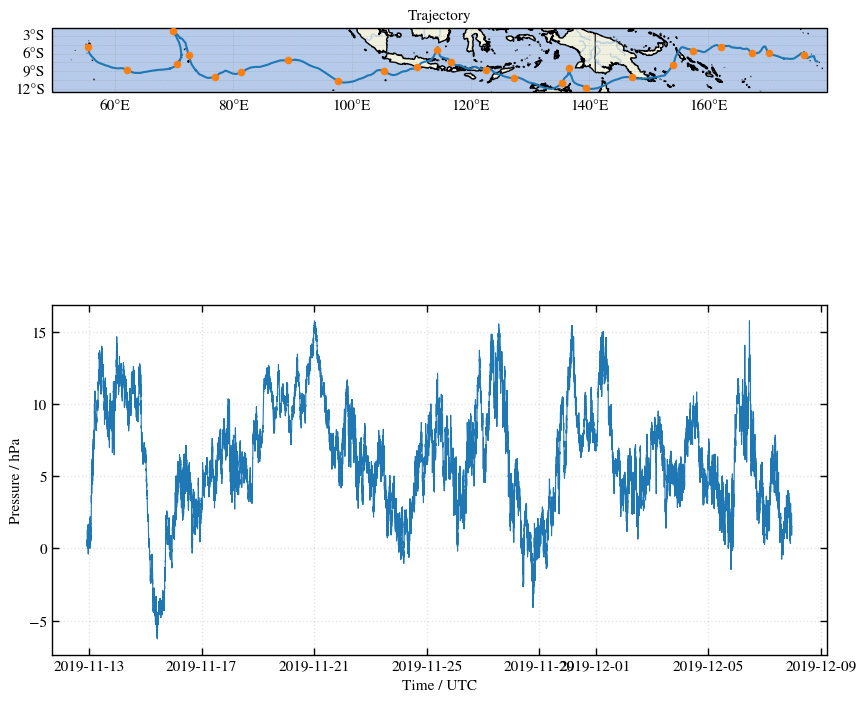

In [3]:
lons = ds['lon'].values
lats = ds['lat'].values

gskw = {"hspace": 0.06, "wspace": 0.05, "height_ratios": [1, 1]}
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(10, 10))

# --- Karten-Achse ---
ax_map = fig.add_subplot(2, 1, 1, projection=proj)

ax_map.add_feature(cfeature.LAND, alpha=0.9)
ax_map.add_feature(cfeature.OCEAN, alpha=0.7)
ax_map.add_feature(cfeature.COASTLINE, linewidth=1.0)
ax_map.add_feature(cfeature.BORDERS, linewidth=0.8)
ax_map.add_feature(cfeature.LAKES, alpha=0.6)
ax_map.add_feature(cfeature.RIVERS, alpha=0.5)

gl = ax_map.gridlines(draw_labels=True, linewidth=0.4, alpha=0.6)
gl.right_labels = False
gl.top_labels = False

ax_map.plot(lons, lats, transform=proj, linewidth=1.5)
ax_map.scatter(lons[::120*24], lats[::120*24], s=20, color="tab:orange", transform=proj, zorder=5)

ax_map.set_title("Trajectory")

# --- Pressure timeseries ---
ax_ts = fig.add_subplot(2, 1, 2)
ax_ts.plot(ds['time'], ds['u'])
ax_ts.set_ylabel("Pressure / hPa")
ax_ts.set_xlabel("Time / UTC")